c:\Users\babie\OneDrive\바탕 화면\임시 ms 폴더\ch03


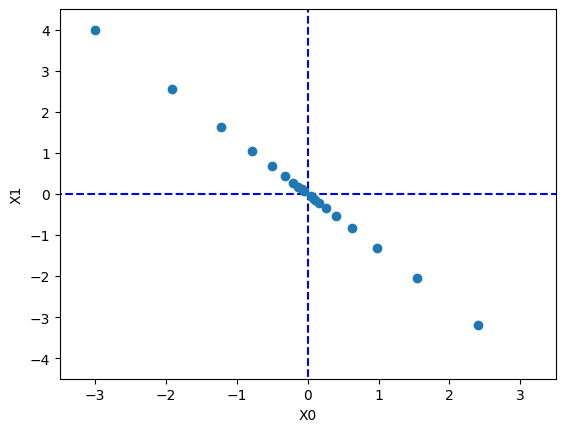

In [12]:
# coding: utf-8
import os, sys
print(os.getcwd())

import numpy as np
import matplotlib.pylab as plt

# from gradient_2d import numerical_gradient

def _numerical_gradient_no_batch(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x) # x와 형상이 같은 배열을 생성

    for idx in range(x.size):
        tmp_val = x[idx]

        # f(x+h) 계산
        x[idx] = float(tmp_val) + h
        fxh1 = f(x)

        # f(x-h) 계산
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val # 값 복원

    return grad

def numerical_gradient(f, X):
    if X.ndim == 1:
        return _numerical_gradient_no_batch(f, X)
    else:
        grad = np.zeros_like(X)
        for idx, x in enumerate(X):
            grad[idx] = _numerical_gradient_no_batch(f, x)
        return grad

def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x
    x_history = []

    for i in range(step_num):
        x_history.append(x.copy())
        grad = numerical_gradient(f, x)
        x -= lr * grad

    return x, np.array(x_history)

def function_2(x):
    return x[0]**2 + x[1]**2

init_x = np.array([-3.0, 4.0])
lr = 0.9
step_num = 20
x, x_history = gradient_descent(function_2, init_x, lr=lr, step_num=step_num)

plt.plot([-5, 5], [0, 0], '--b')
plt.plot([0, 0], [-5, 5], '--b')
plt.plot(x_history[:,0], x_history[:,1], 'o')

plt.xlim(-3.5, 3.5)
plt.ylim(-4.5, 4.5)
plt.xlabel("X0")
plt.ylabel("X1")
plt.show()


c:\Users\babie\OneDrive\바탕 화면\임시 ms 폴더\ch03


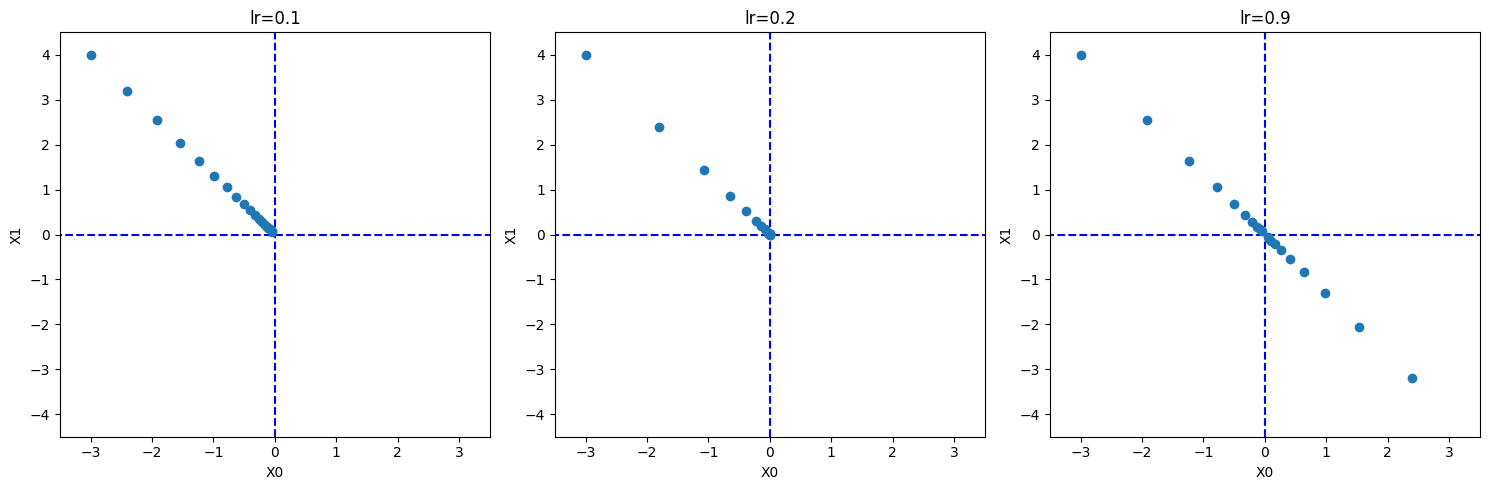

In [13]:
# coding: utf-8
import os, sys
print(os.getcwd())

import numpy as np
import matplotlib.pylab as plt

# from gradient_2d import numerical_gradient

def _numerical_gradient_no_batch(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x) # x와 형상이 같은 배열을 생성

    for idx in range(x.size):
        tmp_val = x[idx]

        # f(x+h) 계산
        x[idx] = float(tmp_val) + h
        fxh1 = f(x)

        # f(x-h) 계산
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val # 값 복원

    return grad

def numerical_gradient(f, X):
    if X.ndim == 1:
        return _numerical_gradient_no_batch(f, X)
    else:
        grad = np.zeros_like(X)
        for idx, x in enumerate(X):
            grad[idx] = _numerical_gradient_no_batch(f, x)
        return grad

def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x.copy()  # 여기도 copy 추가
    x_history = []

    for i in range(step_num):
        x_history.append(x.copy())
        grad = numerical_gradient(f, x)
        x -= lr * grad

    return x, np.array(x_history)

def function_2(x):
    return x[0]**2 + x[1]**2

step_num = 20

# 여러 학습률 설정
learning_rates = [0.1, 0.2, 0.9]

# 3개의 서브플롯 생성
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, lr in enumerate(learning_rates):
    init_x = np.array([-3.0, 4.0])  # 매번 새로 초기화
    x, x_history = gradient_descent(function_2, init_x, lr=lr, step_num=step_num)
    
    axes[idx].plot([-5, 5], [0, 0], '--b')
    axes[idx].plot([0, 0], [-5, 5], '--b')
    axes[idx].plot(x_history[:,0], x_history[:,1], 'o')
    
    axes[idx].set_xlim(-3.5, 3.5)
    axes[idx].set_ylim(-4.5, 4.5)
    axes[idx].set_xlabel("X0")
    axes[idx].set_ylabel("X1")
    axes[idx].set_title(f"lr={lr}")

plt.tight_layout()
plt.show()